# PURITY Parquet Alignment Debug View

This notebook inspects one row from the current DetResponse ML parquet output.

It is designed around the newer PURITY-style schema:

- ATAR hit columns: `atar_*`
- LYSO hit columns: `lyso_*`
- Event truth: `truth_theta`, `truth_phi`, `truth_positron_energy`, and `truth_*` positions
- Time slices: `atar_slice_id`, `atar_slice_mean_t`, `lyso_slice`, `lyso_slice_mean_t`

The plots are meant to answer: does the event-level positron truth direction look consistent with the hit content and time slicing?

In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq

# ---------- config ----------
PARQUET_PATH = Path('/home/jack/python_projects/pioneerML/data/purity_inputs/no_mixing/all_ml_000.parquet')
ROW_INDEX = 8
FOCUS_SLICE = 0
# ----------------------------

In [2]:
def load_row_dict(path: Path, row_index: int):
    table = pq.read_table(path).slice(row_index, 1)
    data = table.to_pydict()
    return {k: v[0] for k, v in data.items()}


def require_col(row, name):
    if name not in row:
        raise KeyError(f"Missing required column '{name}'. Available keys: {sorted(row.keys())}")
    return row[name]


def optional_col(row, name, default=None):
    return row.get(name, default)


def as_float_array(values):
    return np.asarray(values if values is not None else [], dtype=float)


def as_int_array(values):
    return np.asarray(values if values is not None else [], dtype=int)


def is_finite_triplet(x, y, z):
    return all(np.isfinite(v) for v in (x, y, z))


def choose_truth_anchor(row):
    candidates = [
        ('truth_positron_start', 'positron start'),
        ('truth_muon_stop', 'muon stop'),
        ('truth_pion_stop', 'pion stop'),
    ]
    for prefix, label in candidates:
        x = float(optional_col(row, f'{prefix}_x', np.nan))
        y = float(optional_col(row, f'{prefix}_y', np.nan))
        z = float(optional_col(row, f'{prefix}_z', np.nan))
        if is_finite_triplet(x, y, z):
            return np.array([x, y, z], dtype=float), label
    raise ValueError('Could not find a finite truth anchor in the row.')


def direction_from_theta_phi(theta, phi):
    return np.array([
        math.sin(theta) * math.cos(phi),
        math.sin(theta) * math.sin(phi),
        math.cos(theta),
    ], dtype=float)


def summarize_counter(values):
    counts = Counter(int(v) for v in values)
    if not counts:
        return 'none'
    return ', '.join(f'{value}:{count}' for value, count in counts.most_common(4))


def extract_detector_payload(row, prefix):
    payload = {
        'x': as_float_array(require_col(row, f'{prefix}_x')),
        'y': as_float_array(require_col(row, f'{prefix}_y')),
        'z': as_float_array(require_col(row, f'{prefix}_z')),
        't': as_float_array(require_col(row, f'{prefix}_t')),
        'e': as_float_array(require_col(row, f'{prefix}_E')),
        'pdg': as_int_array(optional_col(row, f'{prefix}_pdg', [])),
        'origin': as_int_array(optional_col(row, f'{prefix}_origin', [])),
    }
    if prefix == 'atar':
        payload['view'] = as_int_array(require_col(row, 'atar_view'))
        payload['slice_id'] = as_int_array(require_col(row, 'atar_slice_id'))
        payload['slice_mean_t'] = as_float_array(require_col(row, 'atar_slice_mean_t'))
        payload['truth_t'] = as_float_array(optional_col(row, 'atar_truth_t', []))
    else:
        payload['slice_id'] = as_int_array(optional_col(row, 'lyso_slice', []))
        payload['slice_mean_t'] = as_float_array(optional_col(row, 'lyso_slice_mean_t', []))
    return payload


row = load_row_dict(PARQUET_PATH, ROW_INDEX)
atar = extract_detector_payload(row, 'atar')
lyso = extract_detector_payload(row, 'lyso')
anchor, anchor_label = choose_truth_anchor(row)
direction = direction_from_theta_phi(float(require_col(row, 'truth_theta')), float(require_col(row, 'truth_phi')))

print(f'Loaded row {ROW_INDEX} from {PARQUET_PATH}')
print('schema_version:', optional_col(row, 'schema_version', 'UNKNOWN'))
print('event_id:', optional_col(row, 'event_id', 'UNKNOWN'))
print('num columns:', len(row))
print('columns:', sorted(row.keys()))
print('ATAR hits:', len(atar['x']))
print('LYSO hits:', len(lyso['x']))
print(f'anchor: {anchor_label} @ ({anchor[0]:.3f}, {anchor[1]:.3f}, {anchor[2]:.3f})')
print(f'truth direction: ({direction[0]:.5f}, {direction[1]:.5f}, {direction[2]:.5f})')
print('truth_positron_energy:', float(optional_col(row, 'truth_positron_energy', np.nan)))

Loaded row 8 from /home/jack/python_projects/pioneerML/data/purity_inputs/no_mixing/all_ml_000.parquet
schema_version: detresponse-purity-v1
event_id: 8
num columns: 43
columns: ['atar_E', 'atar_origin', 'atar_pdg', 'atar_slice_id', 'atar_slice_mean_t', 'atar_t', 'atar_truth_t', 'atar_view', 'atar_x', 'atar_y', 'atar_z', 'event_id', 'lyso_E', 'lyso_origin', 'lyso_pdg', 'lyso_slice', 'lyso_slice_mean_t', 'lyso_t', 'lyso_x', 'lyso_y', 'lyso_z', 'schema_version', 'truth_muon_start_x', 'truth_muon_start_y', 'truth_muon_start_z', 'truth_muon_stop_x', 'truth_muon_stop_y', 'truth_muon_stop_z', 'truth_phi', 'truth_pion_start_x', 'truth_pion_start_y', 'truth_pion_start_z', 'truth_pion_stop_x', 'truth_pion_stop_y', 'truth_pion_stop_z', 'truth_positron_energy', 'truth_positron_start_x', 'truth_positron_start_y', 'truth_positron_start_z', 'truth_positron_stop_x', 'truth_positron_stop_y', 'truth_positron_stop_z', 'truth_theta']
ATAR hits: 70
LYSO hits: 5
anchor: positron start @ (3.726, -2.399, 3.7

In [3]:
unique_slices = sorted(int(v) for v in np.unique(atar['slice_id'])) if len(atar['slice_id']) else []
lyso_by_slice = defaultdict(lambda: np.array([], dtype=int))
if len(lyso['slice_id']) > 0:
    for slice_id in sorted(int(v) for v in np.unique(lyso['slice_id'])):
        lyso_by_slice[slice_id] = np.where(lyso['slice_id'] == slice_id)[0]

print('Per-slice summary:')
for slice_id in unique_slices:
    hit_idx = np.where(atar['slice_id'] == slice_id)[0]
    lyso_idx = lyso_by_slice.get(slice_id, np.array([], dtype=int))
    x_hits = int(np.sum(atar['view'][hit_idx] == 0))
    y_hits = int(np.sum(atar['view'][hit_idx] == 1))
    time_min = float(np.min(atar['t'][hit_idx])) if len(hit_idx) else float('nan')
    time_max = float(np.max(atar['t'][hit_idx])) if len(hit_idx) else float('nan')
    mean_t = float(atar['slice_mean_t'][hit_idx[0]]) if len(hit_idx) else float('nan')
    print(
        f'  slice {slice_id:2d}: '
        f"atar_hits={len(hit_idx):3d} (x={x_hits:3d}, y={y_hits:3d}) "
        f"lyso_hits={len(lyso_idx):2d} "
        f"time=[{time_min:8.3f}, {time_max:8.3f}] "
        f"mean_t={mean_t:8.3f} "
        f"origin={summarize_counter(atar['origin'][hit_idx])} "
        f"pdg={summarize_counter(atar['pdg'][hit_idx])}"
    )

Per-slice summary:
  slice  0: atar_hits=  2 (x=  1, y=  1) lyso_hits= 3 time=[  27.834,   27.838] mean_t=  28.227 origin=0:2 pdg=4:2
  slice  1: atar_hits=  4 (x=  3, y=  1) lyso_hits= 0 time=[   5.905,    6.126] mean_t=   6.011 origin=0:4 pdg=2:4
  slice  2: atar_hits= 26 (x= 14, y= 12) lyso_hits= 0 time=[   3.652,    4.425] mean_t=   4.013 origin=0:26 pdg=1:25, 3:1
  slice  3: atar_hits= 38 (x= 14, y= 24) lyso_hits= 1 time=[  26.975,   27.722] mean_t=  27.444 origin=0:38 pdg=4:38


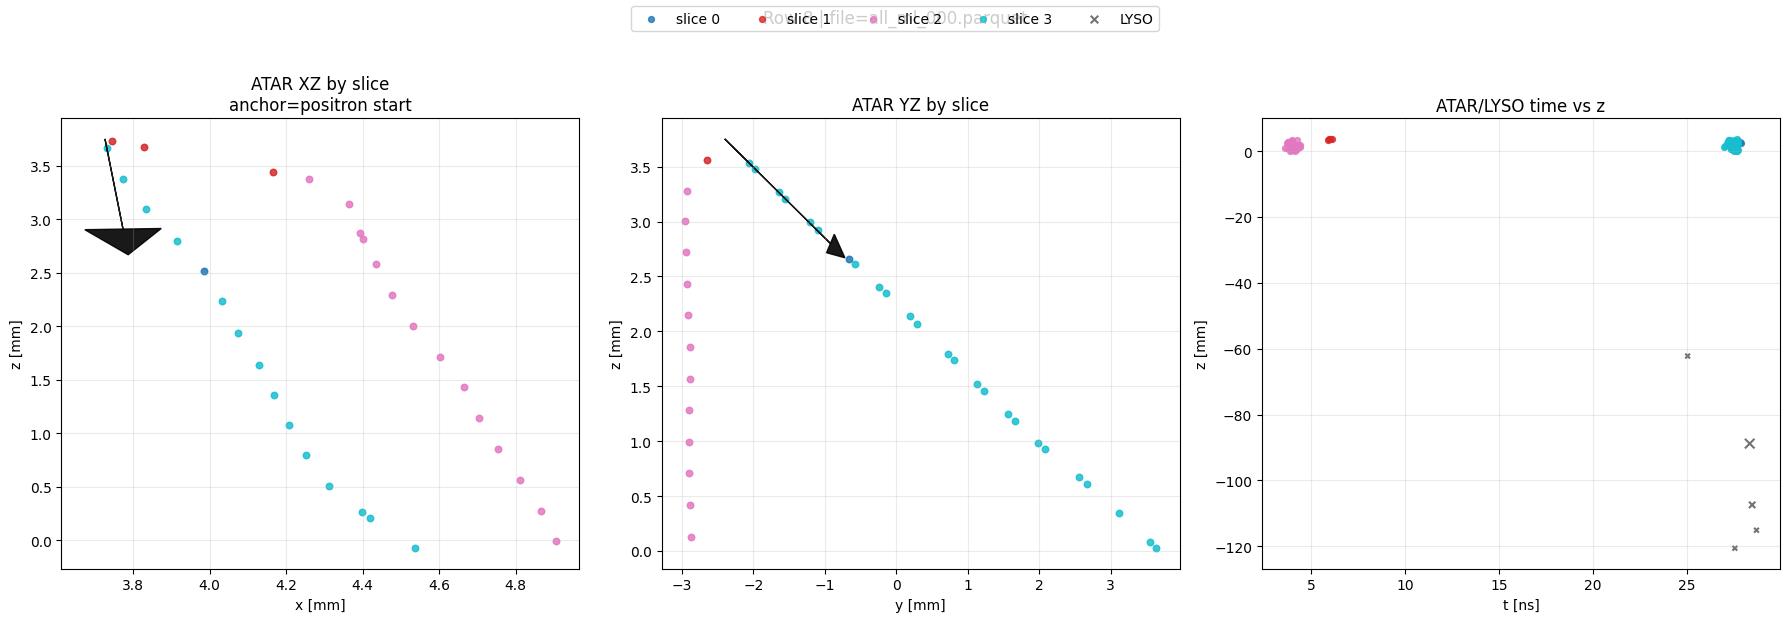

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax_xz, ax_yz, ax_tz = axes

z_span = float(np.ptp(atar['z'])) if len(atar['z']) else 1.0
arrow_scale = max(2.0, 0.2 * z_span)
cmap = plt.get_cmap('tab10', max(1, len(unique_slices)))

for color_index, slice_id in enumerate(unique_slices or [0]):
    color = cmap(color_index)
    mask = (atar['slice_id'] == slice_id) if len(atar['slice_id']) else np.zeros(len(atar['x']), dtype=bool)
    x_mask = mask & (atar['view'] == 0)
    y_mask = mask & (atar['view'] == 1)

    if np.any(x_mask):
        ax_xz.scatter(atar['x'][x_mask], atar['z'][x_mask], s=22, alpha=0.85, color=color, label=f'slice {slice_id}')
    if np.any(y_mask):
        ax_yz.scatter(atar['y'][y_mask], atar['z'][y_mask], s=22, alpha=0.85, color=color, label=f'slice {slice_id}')
    if np.any(mask):
        ax_tz.scatter(atar['t'][mask], atar['z'][mask], s=18, alpha=0.8, color=color, label=f'slice {slice_id}')

if len(lyso['x']) > 0:
    ax_tz.scatter(
        lyso['t'],
        lyso['z'],
        s=np.clip(lyso['e'] * 4.0, 12.0, 80.0),
        alpha=0.55,
        marker='x',
        color='black',
        label='LYSO',
    )

ax_xz.arrow(
    anchor[0], anchor[2],
    direction[0] * arrow_scale, direction[2] * arrow_scale,
    width=0.0,
    head_width=0.10 * arrow_scale,
    head_length=0.12 * arrow_scale,
    color='black',
    alpha=0.9,
    length_includes_head=True,
)
ax_yz.arrow(
    anchor[1], anchor[2],
    direction[1] * arrow_scale, direction[2] * arrow_scale,
    width=0.0,
    head_width=0.10 * arrow_scale,
    head_length=0.12 * arrow_scale,
    color='black',
    alpha=0.9,
    length_includes_head=True,
)

ax_xz.set_title(f'ATAR XZ by slice\nanchor={anchor_label}')
ax_xz.set_xlabel('x [mm]')
ax_xz.set_ylabel('z [mm]')

ax_yz.set_title('ATAR YZ by slice')
ax_yz.set_xlabel('y [mm]')
ax_yz.set_ylabel('z [mm]')

ax_tz.set_title('ATAR/LYSO time vs z')
ax_tz.set_xlabel('t [ns]')
ax_tz.set_ylabel('z [mm]')

for axis in axes:
    axis.grid(alpha=0.25)

handles, labels = ax_xz.get_legend_handles_labels()
handles_tz, labels_tz = ax_tz.get_legend_handles_labels()
legend_entries = {}
for handle, label in list(zip(handles, labels)) + list(zip(handles_tz, labels_tz)):
    legend_entries[label] = handle
if legend_entries:
    fig.legend(legend_entries.values(), legend_entries.keys(), loc='upper center', ncol=min(8, len(legend_entries)))

fig.suptitle(f'Row {ROW_INDEX} | file={PARQUET_PATH.name}', y=1.03)
fig.tight_layout()
plt.show()

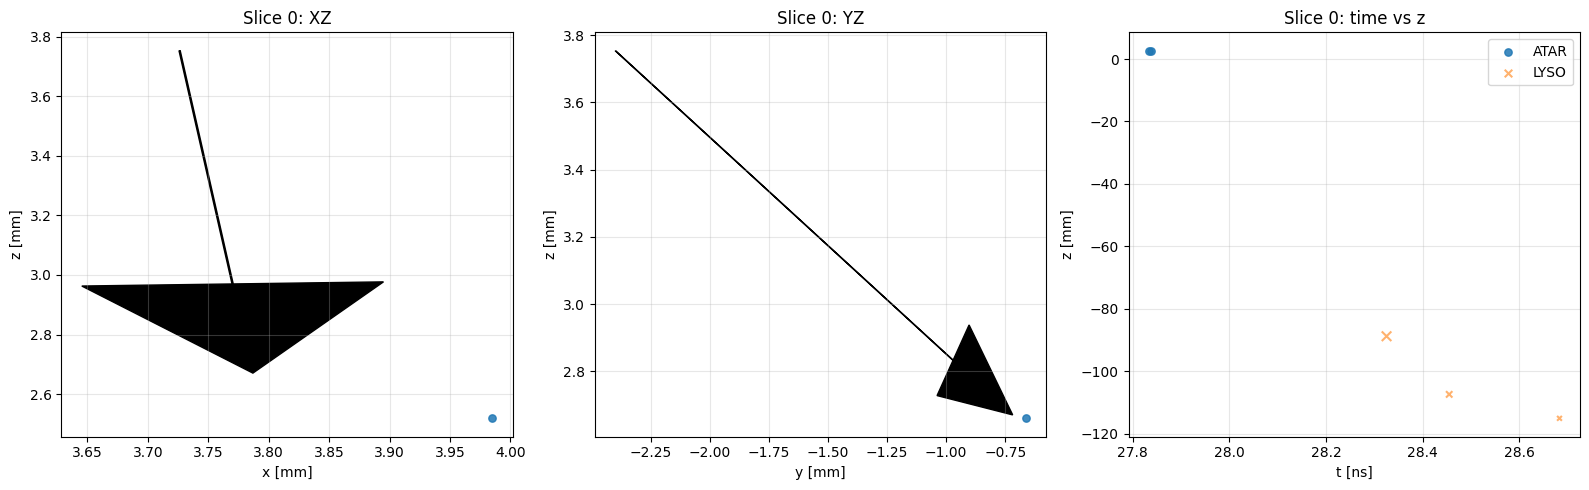

In [5]:
slice_mask = (atar['slice_id'] == FOCUS_SLICE)
x_mask = slice_mask & (atar['view'] == 0)
y_mask = slice_mask & (atar['view'] == 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax1, ax2, ax3 = axes

ax1.scatter(atar['x'][x_mask], atar['z'][x_mask], s=28, alpha=0.85)
ax1.arrow(anchor[0], anchor[2], direction[0] * 2.0, direction[2] * 2.0,
          head_width=0.25, head_length=0.30, length_includes_head=True, color='black')
ax1.set_title(f'Slice {FOCUS_SLICE}: XZ')
ax1.set_xlabel('x [mm]')
ax1.set_ylabel('z [mm]')
ax1.grid(alpha=0.3)

ax2.scatter(atar['y'][y_mask], atar['z'][y_mask], s=28, alpha=0.85)
ax2.arrow(anchor[1], anchor[2], direction[1] * 2.0, direction[2] * 2.0,
          head_width=0.25, head_length=0.30, length_includes_head=True, color='black')
ax2.set_title(f'Slice {FOCUS_SLICE}: YZ')
ax2.set_xlabel('y [mm]')
ax2.set_ylabel('z [mm]')
ax2.grid(alpha=0.3)

ax3.scatter(atar['t'][slice_mask], atar['z'][slice_mask], s=28, alpha=0.85, label='ATAR')
if len(lyso['slice_id']) > 0:
    lyso_mask = (lyso['slice_id'] == FOCUS_SLICE)
    if np.any(lyso_mask):
        ax3.scatter(lyso['t'][lyso_mask], lyso['z'][lyso_mask], s=np.clip(lyso['e'][lyso_mask] * 4.0, 12.0, 80.0), alpha=0.6, marker='x', label='LYSO')
ax3.set_title(f'Slice {FOCUS_SLICE}: time vs z')
ax3.set_xlabel('t [ns]')
ax3.set_ylabel('z [mm]')
ax3.grid(alpha=0.3)
if ax3.has_data():
    ax3.legend()

plt.tight_layout()
plt.show()